# 04 — Process clean ρw files (CHIME / simulation format)

This notebook applies the **phytospec** spectral algorithms to pre-processed, clean ρw files  
that are **not** raw PANTHYR acquisitions. These files contain only reflectance spectra  
with no acquisition metadata (no datetime, SZA, Ld/Ed).

### Typical input format
```
icase  350.0  355.0  360.0  ...  895.0
0000000  0.00279  0.00273  ...
0000001  0.00269  0.00263  ...
```
Space-separated, **5 nm resolution**, wavelengths as column headers, `icase` as row index.

### Key differences vs. PANTHYR pipeline
| Parameter | PANTHYR | CHIME/clean files |
|---|---|---|
| `D2_DELTA` | 2.5 nm | **5.0 nm** |
| Geometry QC | SZA + Ld/Ed filter | **skipped** (no metadata) |
| One-per-day selection | yes | **skipped** (no datetime) |
| Input | one CSV per acquisition | **one file = many spectra** |

## 0 — Configuration

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg

# ── Input file ────────────────────────────────────────────────────────────────
# Both absolute paths and paths relative to the project root are accepted.
INPUT_FILE  = cfg.DATA_RAW / "CHIME"/ "chime_10_belgium"     #

# Label used in plot titles and output filename - Visualization and output files will be named according to this label.
DATASET_LABEL = "chime_10_belgium"  # e.g., "chime_10_meas_01"           

# ── Output ───────────────────────────────────────────────────────────────────
OUTPUT_CSV = cfg.DATA_PROCESSED / f"dataset_{DATASET_LABEL}.csv"

# ── Algorithm override for 5 nm resolution ───────────────────────────────────
# PANTHYR has 2.5 nm spacing → D2_DELTA = 2.5
# CHIME / clean files have 5 nm spacing → must use 5.0
# chime_05 files → D2_DELTA_OVERRIDE = 5.0
# chime_10 files → D2_DELTA_OVERRIDE = 10.0
D2_DELTA_OVERRIDE   = 10.0   # nm  — set to match actual wavelength spacing
D2_NSMOOTH_OVERRIDE = 2     # number of 5-pt smoothing passes 

print(f"Input  : {INPUT_FILE}")
print(f"Output : {OUTPUT_CSV}")
print(f"D2 delta: {D2_DELTA_OVERRIDE} nm | smoothing passes: {D2_NSMOOTH_OVERRIDE}")

Input  : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\raw\CHIME\chime_10_belgium
Output : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\dataset_chime_10_belgium.csv
D2 delta: 10.0 nm | smoothing passes: 2


## 1 — Read the clean ρw file

In [89]:
def read_clean_rhow(filepath: Path) -> tuple[np.ndarray, np.ndarray, list]:
    """
    Read a space-separated clean ρw file.

    Expected format
    ---------------
    Header row : 'icase  wl1  wl2  ...  wlN'
    Data rows  : 'XXXXXXX  r1  r2  ...  rN'

    Returns
    -------
    RHOW    : (N_spectra x N_wavelengths) float array
    wl      : (N_wavelengths,) wavelength array [nm]
    icases  : list of icase strings
    """
    filepath = Path(filepath)
    df = pd.read_csv(filepath, sep=r'\s+', header=0, index_col=0)

    wl     = df.columns.astype(float).values
    RHOW   = df.values.astype(float)
    icases = list(df.index.astype(str))

    # Set negative values to NaN (same convention as build_datacube)
    RHOW[RHOW < 0] = np.nan

    print(f"[read] {filepath.name}")
    print(f"       {RHOW.shape[0]} spectra  |  {len(wl)} wavelengths  "
          f"|  {wl[0]:.0f}–{wl[-1]:.0f} nm  |  step {wl[1]-wl[0]:.1f} nm")
    return RHOW, wl, icases


RHOW, wl, icases = read_clean_rhow(INPUT_FILE)
N = len(icases)
actual_delta = float(wl[1] - wl[0])

# Safety check — warn if the override does not match the actual spacing
if abs(actual_delta - D2_DELTA_OVERRIDE) > 0.1:
    print(f"\n ***  WARNING: actual wavelength spacing is {actual_delta:.1f} nm "
          f"but D2_DELTA_OVERRIDE = {D2_DELTA_OVERRIDE} nm.")
    print("   Update D2_DELTA_OVERRIDE in the Configuration cell above.")
else:
    print(f"\n Wavelength spacing matches D2_DELTA_OVERRIDE ({actual_delta:.1f} nm)")

[read] chime_10_belgium
       779 spectra  |  60 wavelengths  |  350–940 nm  |  step 10.0 nm

 Wavelength spacing matches D2_DELTA_OVERRIDE (10.0 nm)


## 2 — Quick look at raw spectra

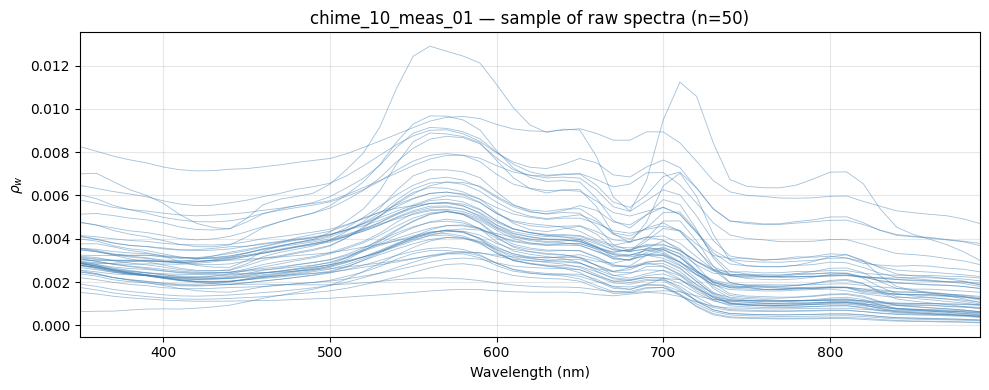

ρw range: 0.00011 – 0.02453


In [79]:
fig, ax = plt.subplots(figsize=(10, 4))
# plot up to 50 spectra to avoid overloading the figure
plot_idx = np.linspace(0, N-1, min(N, 50), dtype=int)
for i in plot_idx:
    ax.plot(wl, RHOW[i, :], lw=0.6, alpha=0.5, color='steelblue')
ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
       title=f'{DATASET_LABEL} — sample of raw spectra (n={len(plot_idx)})',
       xlim=(wl[0], wl[-1]))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"ρw range: {np.nanmin(RHOW):.5f} – {np.nanmax(RHOW):.5f}")

## 3 — Minimal QC  
No geometry metadata available (no SZA, no Ld/Ed).  
We only remove spectra with too many NaN values.

In [90]:
NAN_MAX = 10   # max allowed NaN wavelengths per spectrum (same as cfg.QC_NAN_MAX)

n_nan  = np.sum(np.isnan(RHOW), axis=1)
keep   = n_nan < NAN_MAX

print(f"QC — NaN filter (>{NAN_MAX} NaN bands):")
print(f"  Removed : {(~keep).sum()}")
print(f"  Retained: {keep.sum()} / {N}")

RHOW_qc   = RHOW[keep, :]
icases_qc = [ic for ic, k in zip(icases, keep) if k]
N_qc      = len(icases_qc)

QC — NaN filter (>10 NaN bands):
  Removed : 0
  Retained: 779 / 779


## 4 — Compute spectral indices

In [91]:
CHL  = np.full(N_qc, np.nan)
MALH = np.full(N_qc, np.nan)
PLUB = np.zeros(N_qc, dtype=int)
D2R  = np.full((N_qc, len(wl)), np.nan)

for i in range(N_qc):
    rhow_i = RHOW_qc[i, :]
    if np.sum(~np.isnan(rhow_i)) < 50:
        continue

    CHL[i]    = compute_CHL(rhow_i, wl)
    MALH[i]   = compute_MALH(rhow_i, wl)

    #  Use D2_DELTA_OVERRIDE, NOT the default cfg.D2_DELTA (2.5 nm)
    D2R[i, :] = compute_D2(rhow_i, wl,
                            delta=D2_DELTA_OVERRIDE,
                            n_smooth=D2_NSMOOTH_OVERRIDE)
    PLUB[i]   = lubac_phaeo_index(wl, D2R[i, :])

n_valid_chl  = int(np.sum(~np.isnan(CHL)))
n_valid_malh = int(np.sum(~np.isnan(MALH)))
print(f"Computed for {N_qc} spectra:")
print(f"  CHL  valid : {n_valid_chl}")
print(f"  MALH valid : {n_valid_malh}")
print(f"  P. globosa (P_LUB=1) : {int(PLUB.sum())}")
print(f"  Diatoms    (P_LUB=0) : {int((PLUB == 0).sum())}")

Computed for 779 spectra:
  CHL  valid : 0
  MALH valid : 779
  P. globosa (P_LUB=1) : 36
  Diatoms    (P_LUB=0) : 743


## 5 — Build and save the dataset

In [92]:
rhow_cols  = [f"rhow_{w:.1f}"   for w in wl]
d2row_cols = [f"D2rhow_{w:.1f}" for w in wl]

df = pd.DataFrame({
    "icase": icases_qc,
    "CHL":   CHL,
    "MALH":  MALH,
    "P_LUB": PLUB,
})
df = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame(RHOW_qc, columns=rhow_cols).reset_index(drop=True),
    pd.DataFrame(D2R,     columns=d2row_cols).reset_index(drop=True),
], axis=1)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False, float_format="%.8g")

print(f"Saved → {OUTPUT_CSV}")
print(f"Shape : {df.shape[0]} rows × {df.shape[1]} columns")
df[['icase','CHL','MALH','P_LUB']].head(10)

Saved → C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\dataset_chime_10_belgium.csv
Shape : 779 rows × 124 columns


,icase,CHL,MALH,P_LUB
0,0,NaN,-0.001881,0
1,1,NaN,-0.001990,0
2,2,NaN,-0.002197,0
3,3,NaN,-0.003798,0
4,4,NaN,-0.004424,0
5,5,NaN,-0.004158,0
6,6,NaN,-0.002713,0
7,7,NaN,-0.002401,0
8,8,NaN,-0.002554,0
9,9,NaN,0.003585,0


## 6 — Visualisation
### 6a — Spectral signatures by P_LUB class

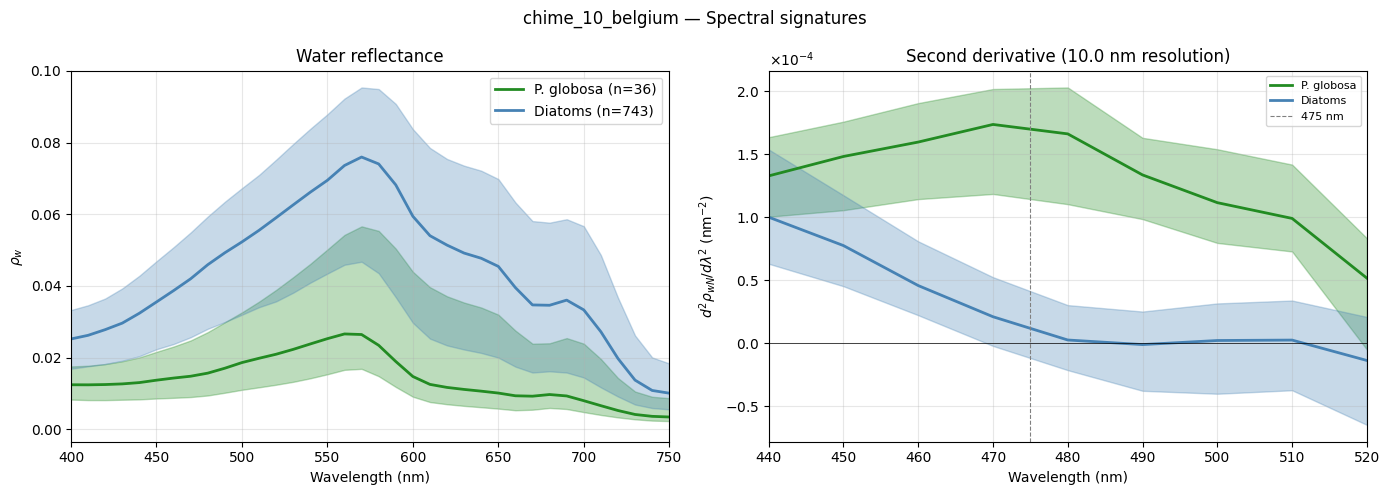

In [93]:
phaeo  = df[df['P_LUB'] == 1]
diatom = df[df['P_LUB'] == 0]

if len(phaeo) == 0:
    print("No P. globosa spectra detected (P_LUB=1) — skipping spectral plot.")
else:
    phaeo_rhow  = phaeo[rhow_cols].values.astype(float)
    diatom_rhow = diatom[rhow_cols].values.astype(float)

    # D2 — zoom 440–520 nm
    wl_mask   = (wl >= 440) & (wl <= 520)
    d2_wl     = wl[wl_mask]
    phaeo_d2  = phaeo[d2row_cols].values[:,  wl_mask].astype(float)
    diatom_d2 = diatom[d2row_cols].values[:, wl_mask].astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.fill_between(wl,
                    np.nanpercentile(phaeo_rhow,  25, axis=0),
                    np.nanpercentile(phaeo_rhow,  75, axis=0),
                    alpha=0.3, color='forestgreen')
    ax.fill_between(wl,
                    np.nanpercentile(diatom_rhow, 25, axis=0),
                    np.nanpercentile(diatom_rhow, 75, axis=0),
                    alpha=0.3, color='steelblue')
    ax.plot(wl, np.nanmedian(phaeo_rhow,  axis=0), color='forestgreen', lw=2, label=f'P. globosa (n={len(phaeo)})')
    ax.plot(wl, np.nanmedian(diatom_rhow, axis=0), color='steelblue',   lw=2, label=f'Diatoms (n={len(diatom)})')
    ax.set(xlabel='Wavelength (nm)', ylabel=r'$\rho_w$',
           title='Water reflectance', xlim=(400, 750))
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.fill_between(d2_wl,
                    np.nanpercentile(phaeo_d2,  25, axis=0),
                    np.nanpercentile(phaeo_d2,  75, axis=0),
                    alpha=0.3, color='forestgreen')
    ax.fill_between(d2_wl,
                    np.nanpercentile(diatom_d2, 25, axis=0),
                    np.nanpercentile(diatom_d2, 75, axis=0),
                    alpha=0.3, color='steelblue')
    ax.plot(d2_wl, np.nanmedian(phaeo_d2,  axis=0), color='forestgreen', lw=2, label='P. globosa')
    ax.plot(d2_wl, np.nanmedian(diatom_d2, axis=0), color='steelblue',   lw=2, label='Diatoms')
    ax.axvline(475, color='grey', linestyle='--', lw=0.8, label='475 nm')
    ax.axhline(0,   color='k', lw=0.5)
    ax.set(xlabel='Wavelength (nm)',
           ylabel=r'$d^2\rho_{wN}/d\lambda^2$ (nm$^{-2}$)',
           title=f'Second derivative ({D2_DELTA_OVERRIDE} nm resolution)', xlim=(440, 520))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle(f'{DATASET_LABEL} — Spectral signatures', fontsize=12)
    plt.tight_layout()
    plt.show()

### 6b — MALH vs CHL scatter

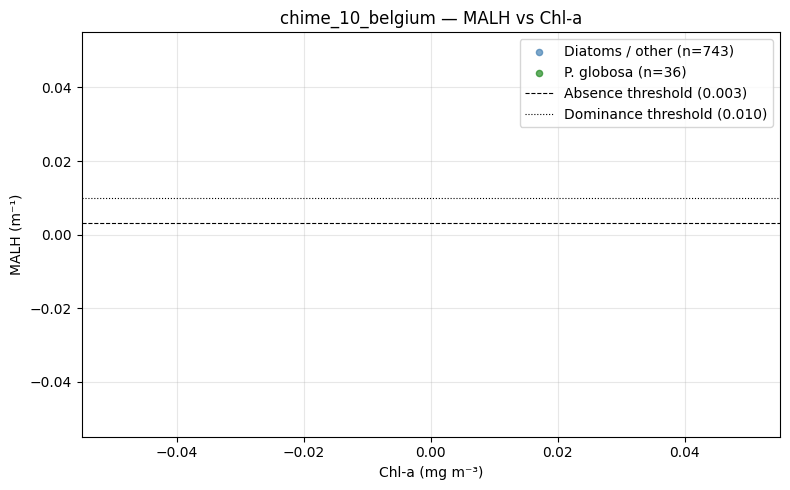

In [94]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, color, name in [(0, 'steelblue', 'Diatoms / other'),
                             (1, 'forestgreen', 'P. globosa')]:
    sub = df[df.P_LUB == label]
    ax.scatter(sub['CHL'], sub['MALH'], c=color, s=20, alpha=0.7, label=f'{name} (n={len(sub)})')

ax.axhline(0.003, color='k', linestyle='--', lw=0.8, label='Absence threshold (0.003)')
ax.axhline(0.010, color='k', linestyle=':',  lw=0.8, label='Dominance threshold (0.010)')
ax.set(xlabel='Chl-a (mg m⁻³)', ylabel='MALH (m⁻¹)',
       title=f'{DATASET_LABEL} — MALH vs Chl-a')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## MALH distribution

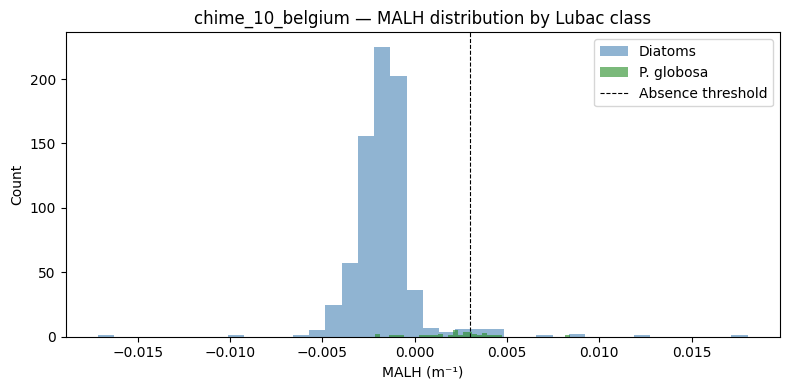

In [95]:
# Add this cell to notebook 04
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(MALH[PLUB == 0], bins=40, alpha=0.6, color='steelblue', label='Diatoms')
ax.hist(MALH[PLUB == 1], bins=40, alpha=0.6, color='forestgreen', label='P. globosa')
ax.axvline(0.003, color='k', linestyle='--', lw=0.8, label='Absence threshold')
ax.set(xlabel='MALH (m⁻¹)', ylabel='Count',
       title=f'{DATASET_LABEL} — MALH distribution by Lubac class')
ax.legend()
plt.tight_layout()
plt.show()

##  D² value diagnostic at the key wavelength

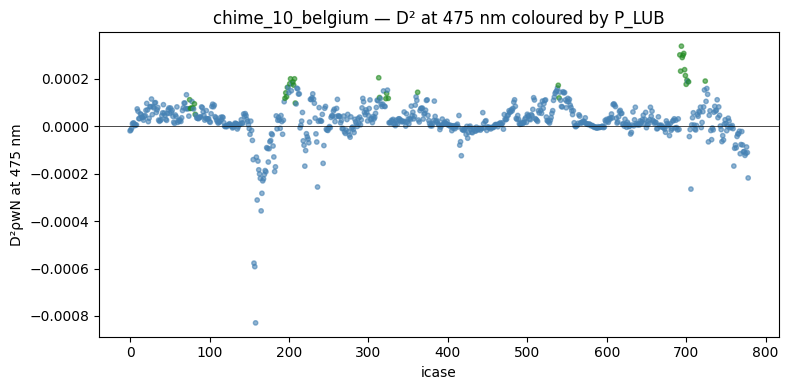

In [96]:
# Check D² at 475 nm specifically — the P. globosa diagnostic wavelength
idx_475 = int(np.argmin(np.abs(wl - 475.0)))
d2_475  = D2R[:, idx_475]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(N_qc), d2_475, 
           c=['forestgreen' if p else 'steelblue' for p in PLUB],
           s=10, alpha=0.6)
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='icase', ylabel='D²ρwN at 475 nm',
       title=f'{DATASET_LABEL} — D² at 475 nm coloured by P_LUB')
plt.tight_layout()
plt.show()

## Finding solution 

In [97]:
# ── Explore recalibrated MALH threshold for CHIME data ───────────────────────
print("MALH percentiles by P_LUB class:")

phaeo_malh = MALH[PLUB == 1]
diatom_malh = MALH[PLUB == 0]

if len(phaeo_malh) == 0:
    print("  P. globosa (n=0): no detections — skipping")
else:
    print(f"  P. globosa (n={len(phaeo_malh)}):")
    print(f"    median={np.nanmedian(phaeo_malh):.5f}  "
          f"p75={np.nanpercentile(phaeo_malh,75):.5f}  "
          f"max={np.nanmax(phaeo_malh):.5f}")

print(f"  Diatoms (n={len(diatom_malh)}):")
print(f"    median={np.nanmedian(diatom_malh):.5f}  "
      f"p75={np.nanpercentile(diatom_malh,75):.5f}  "
      f"max={np.nanmax(diatom_malh):.5f}")

if len(phaeo_malh) > 0:
    candidate_threshold = np.nanpercentile(diatom_malh, 75)
    print(f"\n  Candidate CHIME-specific threshold: {candidate_threshold:.5f} m⁻¹")
    print(f"  (75th percentile of diatom MALH distribution)")
    overlap = np.mean(phaeo_malh <= candidate_threshold) * 100
    print(f"  P. globosa cases below threshold (misclassified): {overlap:.1f}%")

MALH percentiles by P_LUB class:
  P. globosa (n=36):
    median=0.00253  p75=0.00315  max=0.00842
  Diatoms (n=743):
    median=-0.00173  p75=-0.00103  max=0.01803

  Candidate CHIME-specific threshold: -0.00103 m⁻¹
  (75th percentile of diatom MALH distribution)
  P. globosa cases below threshold (misclassified): 8.3%


## Reading other files

[CHIME 5 nm]  779 spectra × 120 bands  | λ 350.0–945.0 nm  | meta cols: ['date', 'icase']
[CHIME 10 nm]  779 spectra × 60 bands  | λ 350.0–940.0 nm  | meta cols: ['date', 'icase']
⚠  File not found: C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\raw\LSTM\AQUATIME_D2.1.0_RD-belgian-coast-lstm-convolved-v0.1.csv


C:\Users\gvillegas\AppData\Local\Temp\ipykernel_15448\970007048.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("plasma", n)


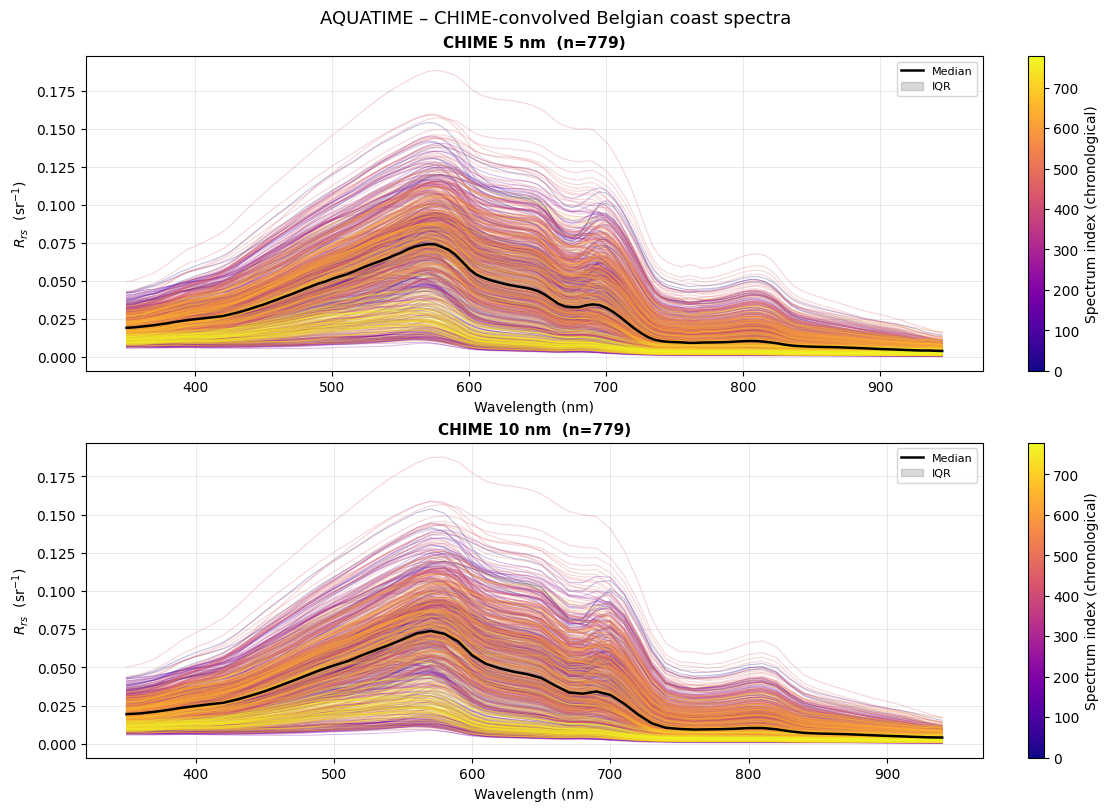

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load and visualise CHIME-convolved spectra
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# ── File paths ────────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")   # adjust as needed

FILES = {
    "CHIME 5 nm":  cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv",
    "CHIME 10 nm": cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv",
    "LSTM":        cfg.DATA_RAW / "LSTM" / "AQUATIME_D2.1.0_RD-belgian-coast-lstm-convolved-v0.1.csv",
}

# ── Helper: detect wavelength columns ─────────────────────────────────────────
def get_wavelength_cols(df):
    """Return columns that look like wavelength values (numeric column names)."""
    wl_cols = []
    for col in df.columns:
        try:
            val = float(col)
            if 300 < val < 1100:   # plausible optical wavelength range (nm)
                wl_cols.append(col)
        except (ValueError, TypeError):
            pass
    return wl_cols

# ── Load & inspect ─────────────────────────────────────────────────────────────
datasets = {}
for label, fpath in FILES.items():
    if not fpath.exists():
        print(f"⚠  File not found: {fpath}")
        continue
    df = pd.read_csv(fpath)
    wl_cols = get_wavelength_cols(df)
    if not wl_cols:
        # Fallback: try row-oriented format (wavelengths in first column)
        print(f"[{label}] No wavelength-like column names found — check format.")
        print(df.head(2))
    else:
        wavelengths = np.array([float(c) for c in wl_cols])
        spectra     = df[wl_cols].values          # shape: (n_spectra, n_bands)
        meta        = df.drop(columns=wl_cols)
        datasets[label] = dict(wl=wavelengths, spectra=spectra, meta=meta, df=df)
        print(f"[{label}]  {spectra.shape[0]} spectra × {spectra.shape[1]} bands  "
              f"| λ {wavelengths[0]:.1f}–{wavelengths[-1]:.1f} nm  "
              f"| meta cols: {list(meta.columns)}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(datasets), 1,
                         figsize=(11, 4 * len(datasets)),
                         sharex=False, constrained_layout=True)

if len(datasets) == 1:
    axes = [axes]

for ax, (label, d) in zip(axes, datasets.items()):
    wl      = d["wl"]
    spectra = d["spectra"]
    n       = spectra.shape[0]

    # Colour-code by row index; use a datetime index if available
    cmap   = cm.get_cmap("plasma", n)
    alphas = np.clip(200 / max(n, 1), 0.05, 0.6)   # thin out when many spectra

    for i, sp in enumerate(spectra):
        ax.plot(wl, sp, color=cmap(i / max(n - 1, 1)), alpha=alphas, lw=0.8)

    # Overlay median ± IQR
    med  = np.nanmedian(spectra, axis=0)
    p25  = np.nanpercentile(spectra, 25, axis=0)
    p75  = np.nanpercentile(spectra, 75, axis=0)
    ax.plot(wl, med, color="black", lw=1.8, label="Median")
    ax.fill_between(wl, p25, p75, color="black", alpha=0.15, label="IQR")

    ax.set_title(f"{label}  (n={n})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("$R_{rs}$  (sr$^{-1}$)")
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)

    # Add colourbar to show temporal spread
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n - 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Spectrum index (chronological)")

plt.suptitle("AQUATIME – CHIME-convolved Belgian coast spectra", fontsize=13)
plt.show()

---
## Notes for interpretation

**D² resolution effect:**  
At 5 nm resolution the second derivative is computed over a coarser grid than PANTHYR (2.5 nm).  
The absolute D² values will be **~4× smaller** (because delta² in the denominator is 4× larger).  
The Lubac classifier uses wavelength positions, not magnitudes, so it is **unaffected**.  
MALH and CHL use `interp_at()` (linear interpolation) and are also **unaffected** by resolution.

**No geometry QC:**  
Since there is no SZA or Ld/Ed information, no glint or sun-angle filter is applied.  
The input files are assumed to be already clean (hence the notebook name).

**CHL validity:**  
The CRAT algorithm requires a NIR-red peak shape (ρw(750) < ρw(672) < ρw(λmax)).  
If many CHL values are NaN, check that the spectra actually show a red peak typical of bloom conditions.